In [2]:
import os
from pathlib import Path
import kagglehub

# Choose where you want kagglehub to store downloads
download_dir = Path("C:\\Users\\rfrantzesk\\Desktop\\sportsbetting\\datasetworld").resolve()
download_dir.mkdir(parents=True, exist_ok=True)

# Tell kagglehub to use this directory as its cache/download location
os.environ["KAGGLEHUB_CACHE"] = str(download_dir)

# Kaggle dataset slug
dataset_slug = "piterfm/fifa-football-world-cup"

# Download latest version
path = kagglehub.dataset_download(dataset_slug)

print("Chosen download/cache directory:", download_dir)
print("Path to dataset files:", path)

# List downloaded files
dataset_path = Path(path)
if dataset_path.exists():
    print("\nFiles in dataset folder:")
    for file in sorted(dataset_path.rglob("*")):
        if file.is_file():
            print(file)
else:
    print("Dataset path does not exist.")

100%|██████████| 187k/187k [00:00<00:00, 376kB/s]

Extracting files...
Chosen download/cache directory: C:\Users\rfrantzesk\Desktop\sportsbetting\datasetworld
Path to dataset files: C:\Users\rfrantzesk\Desktop\sportsbetting\datasetworld\datasets\piterfm\fifa-football-world-cup\versions\26

Files in dataset folder:
C:\Users\rfrantzesk\Desktop\sportsbetting\datasetworld\datasets\piterfm\fifa-football-world-cup\versions\26\fifa_ranking_2022-10-06.csv
C:\Users\rfrantzesk\Desktop\sportsbetting\datasetworld\datasets\piterfm\fifa-football-world-cup\versions\26\fifa_ranking_2026-06-08.csv
C:\Users\rfrantzesk\Desktop\sportsbetting\datasetworld\datasets\piterfm\fifa-football-world-cup\versions\26\matches_1930_2022.csv
C:\Users\rfrantzesk\Desktop\sportsbetting\datasetworld\datasets\piterfm\fifa-football-world-cup\versions\26\schedule_2026.csv
C:\Users\rfrantzesk\Desktop\sportsbetting\datasetworld\datasets\piterfm\fifa-football-world-cup\versions\26\world_cup.csv


In [81]:
import pandas as pd
df=pd.read_csv("C:\\Users\\rfrantzesk\\Desktop\\sportsbetting\\datasetworld\\datasets\\piterfm\\fifa-football-world-cup\\versions\\26\\matches_1930_2022.csv")

In [82]:
dfnew=df[["home_team","away_team","home_score","away_score","Date","Year","Round"]]
df.columns

Index(['home_team', 'away_team', 'home_score', 'home_xg', 'home_penalty',
       'away_score', 'away_xg', 'away_penalty', 'home_manager', 'home_captain',
       'away_manager', 'away_captain', 'Attendance', 'Venue', 'Officials',
       'Round', 'Date', 'Score', 'Referee', 'Notes', 'Host', 'Year',
       'home_goal', 'away_goal', 'home_goal_long', 'away_goal_long',
       'home_own_goal', 'away_own_goal', 'home_penalty_goal',
       'away_penalty_goal', 'home_penalty_miss_long', 'away_penalty_miss_long',
       'home_penalty_shootout_goal_long', 'away_penalty_shootout_goal_long',
       'home_penalty_shootout_miss_long', 'away_penalty_shootout_miss_long',
       'home_red_card', 'away_red_card', 'home_yellow_red_card',
       'away_yellow_red_card', 'home_yellow_card_long',
       'away_yellow_card_long', 'home_substitute_in_long',
       'away_substitute_in_long'],
      dtype='object')

In [83]:
cutoff_date = "1999-05-07"
raw_df1 = dfnew[dfnew["Date"] >= cutoff_date].copy()
raw_df1

,home_team,away_team,home_score,away_score,Date,Year,Round
0,Argentina,France,3,3,2022-12-18,2022,Final
1,Croatia,Morocco,2,1,2022-12-17,2022,Third-place match
2,France,Morocco,2,0,2022-12-14,2022,Semi-finals
3,Argentina,Croatia,3,0,2022-12-13,2022,Semi-finals
4,Morocco,Portugal,1,0,2022-12-10,2022,Quarter-finals
...,...,...,...,...,...,...,...
379,Spain,Slovenia,3,1,2002-06-02,2002,Group stage
380,Republic of Ireland,Cameroon,1,1,2002-06-01,2002,Group stage
381,Uruguay,Denmark,1,2,2002-06-01,2002,Group stage
382,Germany,Saudi Arabia,8,0,2002-06-01,2002,Group stage


In [84]:
raw_df1['Date']

0      2022-12-18
1      2022-12-17
2      2022-12-14
3      2022-12-13
4      2022-12-10
          ...    
379    2002-06-02
380    2002-06-01
381    2002-06-01
382    2002-06-01
383    2002-05-31
Name: Date, Length: 384, dtype: object

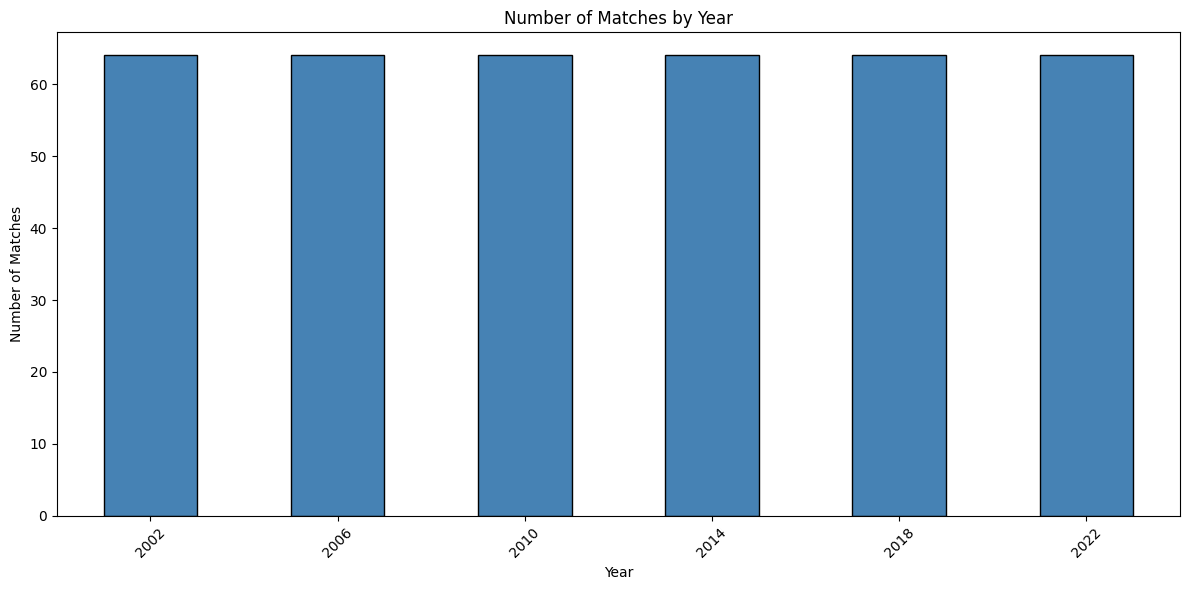

In [85]:
import matplotlib.pyplot as plt
# Replace 'date' with the real date column name if different
raw_df1["Date"] = pd.to_datetime(raw_df1["Date"], errors="coerce")
raw_df1["year"] = raw_df1["Date"].dt.year

# Count matches per year
matches_per_year = raw_df1["year"].value_counts().sort_index()

# Plot
plt.figure(figsize=(12, 6))
matches_per_year.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Number of Matches by Year")
plt.xlabel("Year")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [88]:
raw_df1=raw_df1.drop(raw_df1[["Year"]], axis=1)

In [89]:
raw_df1.head()

,home_team,away_team,home_score,away_score,Date,Round
0,Argentina,France,3,3,2022-12-18,Final
1,Croatia,Morocco,2,1,2022-12-17,Third-place match
2,France,Morocco,2,0,2022-12-14,Semi-finals
3,Argentina,Croatia,3,0,2022-12-13,Semi-finals
4,Morocco,Portugal,1,0,2022-12-10,Quarter-finals


In [90]:
raw_df1["total_goals"] = raw_df1["home_score"] + raw_df1["away_score"]
raw_df1["over25"]      = (raw_df1["total_goals"] > 2.5).astype(int)

In [91]:
raw_df1.head()


,home_team,away_team,home_score,away_score,Date,Round,total_goals,over25
0,Argentina,France,3,3,2022-12-18,Final,6,1
1,Croatia,Morocco,2,1,2022-12-17,Third-place match,3,1
2,France,Morocco,2,0,2022-12-14,Semi-finals,2,0
3,Argentina,Croatia,3,0,2022-12-13,Semi-finals,3,1
4,Morocco,Portugal,1,0,2022-12-10,Quarter-finals,1,0


In [139]:
import numpy as np
import torch

def rolling_team_features(df: pd.DataFrame, team: str, before_date=None, n: int = 5, use_all_data: bool = False) -> dict:

    # auto-detect column names
    home_col = "home_team" if "home_team" in df.columns else "home"
    away_col = "away_team" if "away_team" in df.columns else "away"

    if use_all_data:
        mask = (
            ((df[home_col] == team) | (df[away_col] == team)) &
            (df["home_score"].notna())
        )
    else:
        mask = (
            ((df[home_col] == team) | (df[away_col] == team)) &
            (df["Date"] < before_date) &
            (df["home_score"].notna())
        )

    recent = df[mask].sort_values("Date").tail(n)

    if len(recent) == 0:
        return {
            "avg_gf":      np.nan,
            "avg_ga":      np.nan,
            "avg_total":   np.nan,
            "over25_rate": np.nan,
            "win_rate":    np.nan,
        }

    gf, ga, wins = [], [], 0
    for _, row in recent.iterrows():
        if row[home_col] == team:
            gf.append(row["home_score"])
            ga.append(row["away_score"])
            if row["home_score"] > row["away_score"]:
                wins += 1
        else:
            gf.append(row["away_score"])
            ga.append(row["home_score"])
            if row["away_score"] > row["home_score"]:
                wins += 1

    totals = [g + a for g, a in zip(gf, ga)]
    return {
        "avg_gf":      np.mean(gf),
        "avg_ga":      np.mean(ga),
        "avg_total":   np.mean(totals),
        "over25_rate": np.mean([t > 2.5 for t in totals]),
        "win_rate":    wins / len(recent),
    }

def build_features(df: pd.DataFrame, n: int = 5) -> pd.DataFrame:
    rows = []
    for _, match in df.iterrows():
        h = rolling_team_features(df, match["home_team"], match["Date"], n)
        a = rolling_team_features(df, match["away_team"], match["Date"], n)

        # derive winner from scores
        if match["home_score"] > match["away_score"]:
            winner = "HOME_TEAM"
        elif match["away_score"] > match["home_score"]:
            winner = "AWAY_TEAM"
        else:
            winner = "DRAW"

        rows.append({
            "Date":                 match["Date"],
            "home":                 match["home_team"],
            "away":                 match["away_team"],
            "round":                match["Round"],
            "over25":               match["over25"],
            "total_goals":          match["total_goals"],
            "home_score":           match["home_score"],
            "away_score":           match["away_score"],
            # home rolling
            "h_avg_gf":             h["avg_gf"],
            "h_avg_ga":             h["avg_ga"],
            "h_avg_total":          h["avg_total"],
            "h_over25_rate":        h["over25_rate"],
            "h_win_rate":           h["win_rate"],
            # away rolling
            "a_avg_gf":             a["avg_gf"],
            "a_avg_ga":             a["avg_ga"],
            "a_avg_total":          a["avg_total"],
            "a_over25_rate":        a["over25_rate"],
            "a_win_rate":           a["win_rate"],
            # combined
            "combined_avg_total":   (h["avg_total"]   + a["avg_total"])   / 2,
            "combined_over25_rate": (h["over25_rate"] + a["over25_rate"]) / 2,
            "winner":               winner,
        })

    return pd.DataFrame(rows).dropna()



def predict_match(
    df: pd.DataFrame,
    model,
    scaler,
    home: str,
    away: str,
    match_date: str = None,
    n: int = 5,
    edge_threshold: float = 0.60,
):
    h = rolling_team_features(df, home, before_date=None, n=n, use_all_data=True)
    a = rolling_team_features(df, away, before_date=None, n=n, use_all_data=True)

    features = np.array([[
        h["avg_gf"],  h["avg_ga"],  h["avg_total"],  h["over25_rate"],  h["win_rate"],
        a["avg_gf"],  a["avg_ga"],  a["avg_total"],  a["over25_rate"],  a["win_rate"],
        (h["avg_total"]   + a["avg_total"])   / 2,
        (h["over25_rate"] + a["over25_rate"]) / 2,
    ]], dtype=np.float32)

    features_scaled = scaler.transform(features)
    model.eval()
    with torch.no_grad():
        prob_over  = model(torch.tensor(features_scaled)).item()
    prob_under = 1 - prob_over

    label = match_date if match_date else "upcoming"
    print(f"\n{home} vs {away} — {label}")
    print(f"  P(over 2.5)  = {prob_over:.2%}")
    print(f"  P(under 2.5) = {prob_under:.2%}")

    if prob_over >= edge_threshold:
        print(f"  ✅ BET: OVER 2.5  (edge = {prob_over:.2%})")
    elif prob_under >= edge_threshold:
        print(f"  ✅ BET: UNDER 2.5 (edge = {prob_under:.2%})")
    else:
        print(f"  ⚠️  NO EDGE — skip this match")

    return prob_over

In [140]:
feat_df = build_features(raw_df1, n=5)
feat_df.tail()

,Date,home,away,round,over25,total_goals,home_score,away_score,h_avg_gf,h_avg_ga,...,h_over25_rate,h_win_rate,a_avg_gf,a_avg_ga,a_avg_total,a_over25_rate,a_win_rate,combined_avg_total,combined_over25_rate,winner
363,2002-06-07,Argentina,England,Group stage,0,1,0,1,1.0,0.0,...,0.0,1.0,1.0,1.0,2.0,0.0,0.0,1.5,0.0,AWAY_TEAM
364,2002-06-06,Denmark,Senegal,Group stage,0,2,1,1,2.0,1.0,...,1.0,1.0,1.0,0.0,1.0,0.0,1.0,2.0,0.5,DRAW
365,2002-06-06,Cameroon,Saudi Arabia,Group stage,0,1,1,0,1.0,1.0,...,0.0,0.0,0.0,8.0,8.0,1.0,0.0,5.0,0.5,HOME_TEAM
366,2002-06-06,France,Uruguay,Group stage,0,0,0,0,0.0,1.0,...,0.0,0.0,1.0,2.0,3.0,1.0,0.0,2.0,0.5,DRAW
369,2002-06-05,Germany,Republic of Ireland,Group stage,0,2,1,1,8.0,0.0,...,1.0,1.0,1.0,1.0,2.0,0.0,0.0,5.0,0.5,DRAW


In [141]:
from neuralnetforoverunder import train_model
model, scaler = train_model(feat_df, epochs=1000)

Epoch  20 | Val Acc: 0.464
Epoch  40 | Val Acc: 0.420
Epoch  60 | Val Acc: 0.464
Epoch  80 | Val Acc: 0.464
Epoch 100 | Val Acc: 0.435
Epoch 120 | Val Acc: 0.406
Epoch 140 | Val Acc: 0.435
Epoch 160 | Val Acc: 0.420
Epoch 180 | Val Acc: 0.478
Epoch 200 | Val Acc: 0.435
Epoch 220 | Val Acc: 0.464
Epoch 240 | Val Acc: 0.406
Epoch 260 | Val Acc: 0.420
Epoch 280 | Val Acc: 0.420
Epoch 300 | Val Acc: 0.420
Epoch 320 | Val Acc: 0.391
Epoch 340 | Val Acc: 0.391
Epoch 360 | Val Acc: 0.449
Epoch 380 | Val Acc: 0.464
Epoch 400 | Val Acc: 0.464
Epoch 420 | Val Acc: 0.449
Epoch 440 | Val Acc: 0.449
Epoch 460 | Val Acc: 0.478
Epoch 480 | Val Acc: 0.478
Epoch 500 | Val Acc: 0.449
Epoch 520 | Val Acc: 0.464
Epoch 540 | Val Acc: 0.449
Epoch 560 | Val Acc: 0.493
Epoch 580 | Val Acc: 0.449
Epoch 600 | Val Acc: 0.449
Epoch 620 | Val Acc: 0.507
Epoch 640 | Val Acc: 0.493
Epoch 660 | Val Acc: 0.464
Epoch 680 | Val Acc: 0.478
Epoch 700 | Val Acc: 0.449
Epoch 720 | Val Acc: 0.478
Epoch 740 | Val Acc: 0.449
E

In [142]:
import requests
def get_worldcup_fixtures_sportsdb(season: str = "2026"):
    url = "https://www.thesportsdb.com/api/v1/json/3/eventsseason.php"
    params = {"id": "4429", "s": season}  # 4429 = FIFA World Cup

    r = requests.get(url, params=params).json()

    return [
        {
            "home": m["strHomeTeam"],
            "away": m["strAwayTeam"]
            #"date": m["dateEvent"],
            #"round": m.get("intRound"),
        }
        for m in r["events"]
    ]

# Usage
fixtures = get_worldcup_fixtures_sportsdb("2026")

In [143]:
fixtures
feat_df.rename(columns={'date': 'Date'})

,Date,home,away,round,over25,total_goals,home_score,away_score,h_avg_gf,h_avg_ga,...,h_over25_rate,h_win_rate,a_avg_gf,a_avg_ga,a_avg_total,a_over25_rate,a_win_rate,combined_avg_total,combined_over25_rate,winner
0,2022-12-18,Argentina,France,Final,1,6,3,3,2.2,0.6,...,0.6,0.8,1.8,0.8,2.6,0.6,0.8,2.7,0.6,DRAW
1,2022-12-17,Croatia,Morocco,Third-place match,1,3,2,1,1.2,1.2,...,0.4,0.2,1.0,0.6,1.6,0.2,0.6,2.0,0.3,HOME_TEAM
2,2022-12-14,France,Morocco,Semi-finals,0,2,2,0,2.2,1.0,...,0.8,0.8,1.0,0.2,1.2,0.2,0.6,2.2,0.5,HOME_TEAM
3,2022-12-13,Argentina,Croatia,Semi-finals,1,3,3,0,1.8,1.0,...,0.6,0.6,1.2,0.6,1.8,0.2,0.2,2.3,0.4,HOME_TEAM
4,2022-12-10,Morocco,Portugal,Quarter-finals,0,1,1,0,1.2,0.6,...,0.4,0.4,2.6,1.4,4.0,0.8,0.6,2.9,0.6,HOME_TEAM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
363,2002-06-07,Argentina,England,Group stage,0,1,0,1,1.0,0.0,...,0.0,1.0,1.0,1.0,2.0,0.0,0.0,1.5,0.0,AWAY_TEAM
364,2002-06-06,Denmark,Senegal,Group stage,0,2,1,1,2.0,1.0,...,1.0,1.0,1.0,0.0,1.0,0.0,1.0,2.0,0.5,DRAW
365,2002-06-06,Cameroon,Saudi Arabia,Group stage,0,1,1,0,1.0,1.0,...,0.0,0.0,0.0,8.0,8.0,1.0,0.0,5.0,0.5,HOME_TEAM
366,2002-06-06,France,Uruguay,Group stage,0,0,0,0,0.0,1.0,...,0.0,0.0,1.0,2.0,3.0,1.0,0.0,2.0,0.5,DRAW


In [145]:
for i in range(len(fixtures)):
    predict_match(
    df       = feat_df,
    model    = model,
    scaler   = scaler,
    home     = fixtures[i]["home"],
    away     = fixtures[i]["away"],
    match_date = pd.Timestamp("2026-06-12") ,
    edge_threshold = 0.55,
)


Mexico vs South Africa — 2026-06-12 00:00:00
  P(over 2.5)  = 76.76%
  P(under 2.5) = 23.24%
  ✅ BET: OVER 2.5  (edge = 76.76%)

South Korea vs Czech Republic — 2026-06-12 00:00:00
  P(over 2.5)  = nan%
  P(under 2.5) = nan%
  ⚠️  NO EDGE — skip this match

Canada vs Bosnia-Herzegovina — 2026-06-12 00:00:00
  P(over 2.5)  = nan%
  P(under 2.5) = nan%
  ⚠️  NO EDGE — skip this match

USA vs Paraguay — 2026-06-12 00:00:00
  P(over 2.5)  = nan%
  P(under 2.5) = nan%
  ⚠️  NO EDGE — skip this match

Brazil vs Morocco — 2026-06-12 00:00:00
  P(over 2.5)  = 24.60%
  P(under 2.5) = 75.40%
  ✅ BET: UNDER 2.5 (edge = 75.40%)

Qatar vs Switzerland — 2026-06-12 00:00:00
  P(over 2.5)  = 99.94%
  P(under 2.5) = 0.06%
  ✅ BET: OVER 2.5  (edge = 99.94%)

Haiti vs Scotland — 2026-06-12 00:00:00
  P(over 2.5)  = nan%
  P(under 2.5) = nan%
  ⚠️  NO EDGE — skip this match

Germany vs Curaçao — 2026-06-12 00:00:00
  P(over 2.5)  = nan%
  P(under 2.5) = nan%
  ⚠️  NO EDGE — skip this match

Ivory Coast v